In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

x_img = cv2.imread("Lab0dados/lena.tif")

print(x_img.dtype)
print(x_img.shape)

uint8
(512, 512, 3)


In [3]:
cv2.imwrite("file1.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 80))
cv2.imwrite("file2.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 10))

True

In [4]:
Ia = plt.imread("file1.jpg")
Ib = plt.imread("file2.jpg")

MSE = np.mean((Ia - Ib) ** 2)

Ic = Ia * 1
Id = Ib * 1
MSE = np.mean((Ic - Id) ** 2)

Porg = np.mean(Ic ** 2)
Perr = np.mean((Ic - Id) ** 2)
SNR = 10 * np.log10(Porg / Perr)
print("SNR (dBs): ", SNR)

PSNR = 10 * np.log10(255 ** 2 / Perr)
print("PSNR (dBs): ", PSNR)

SNR (dBs):  3.211537646538954
PSNR (dBs):  31.06790165985945


In [5]:
x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)
cv2.imwrite("file3.bmp", x_img_g)

print(x_img_g.shape)

(512, 512)


C:\Users\Jaime\AppData\Local\Temp\ipykernel_8384\3077081453.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(x_img_g.ravel(), 256, [0, 256])


(262144,)
215


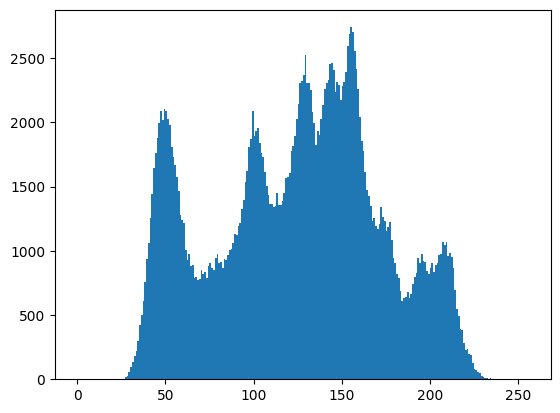

In [17]:
plt.hist(x_img_g.ravel(), 256, [0, 256])

print(x_img_g.ravel().shape)

Igray = plt.imread("file3.bmp")

ar = []
for i in x_img_g.ravel():
    if i in ar:
        continue
    else:
        ar.append(i)
print(len(ar))


Text(0.5, 1.0, 'bit8')

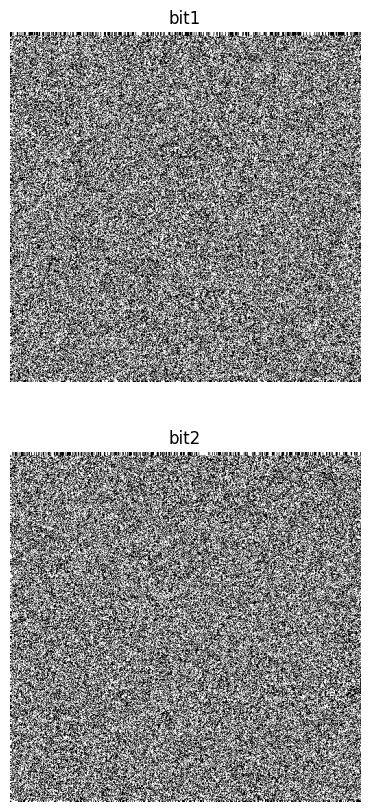

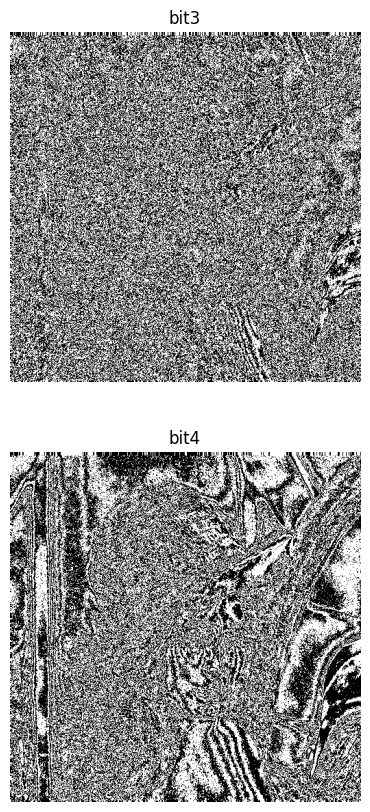

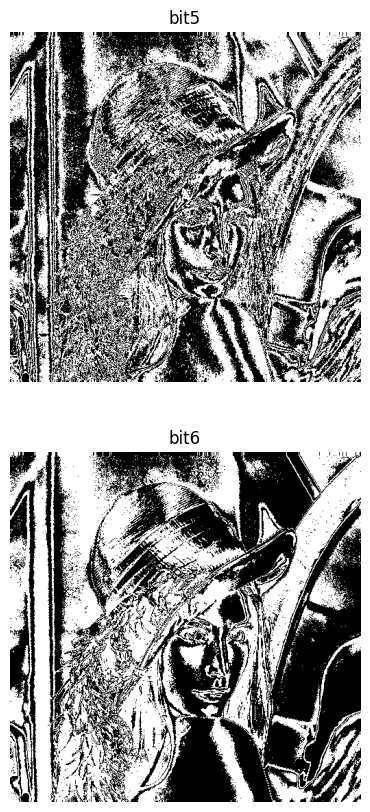

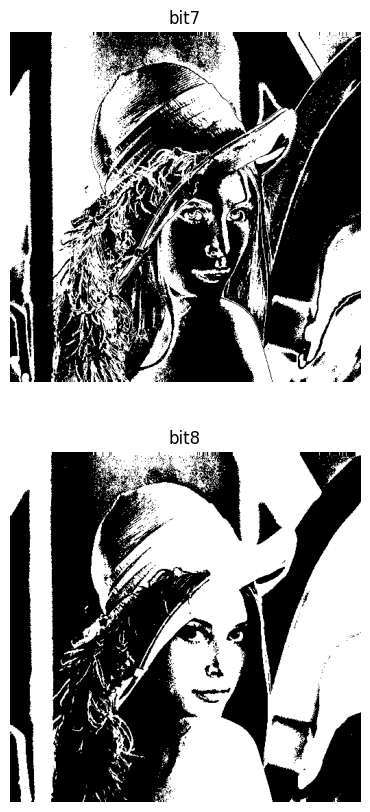

In [10]:
plt.figure(figsize=(20, 10))
plt.subplot(211)
I1 = (Igray%2)*255
plt.imshow(I1, cmap="gray")
plt.axis('off')
plt.title('bit1')
plt.subplot(212)
I2 = ((Igray>>1)%2)*255
plt.imshow(I2, cmap='gray')
plt.axis('off')
plt.title('bit2')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I3 = ((Igray>>2)%2)*255
plt.imshow(I3, cmap='gray')
plt.axis('off')
plt.title('bit3')
plt.subplot(212)
I4 = ((Igray>>3)%2)*255
plt.imshow(I4, cmap='gray')
plt.axis('off')
plt.title('bit4')   
plt.figure(figsize=(20, 10))
plt.subplot(211)
I5 = ((Igray>>4)%2)*255
plt.imshow(I5, cmap='gray')
plt.axis('off')
plt.title('bit5')   
plt.subplot(212)
I6 = ((Igray>>5)%2)*255
plt.imshow(I6, cmap='gray')
plt.axis('off')
plt.title('bit6')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I7 = ((Igray>>6)%2)*255
plt.imshow(I7, cmap='gray')
plt.axis('off')
plt.title('bit7')   
plt.subplot(212)
I8 = ((Igray>>7)%2)*255
plt.imshow(I8, cmap='gray')
plt.axis('off')
plt.title('bit8')


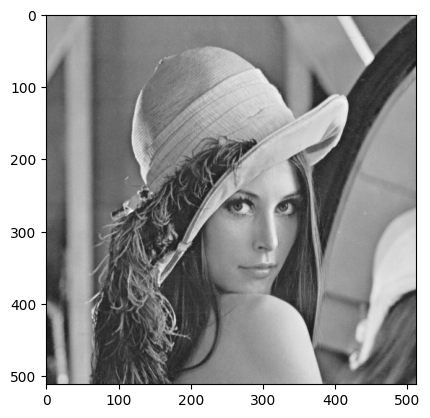

In [31]:
def dither(ar):
    for i in range(len(ar)):
        for j in range(len(ar[i])):
            #ultima linha e ultima coluna
            if ar[len(ar) - 1, len(ar[i]) - 1]:
                pass
            #primeira coluna
            elif ar[i, 0]:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
            #ultima coluna
            elif ar[i, len(ar[i]) - 1]:
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
            #ultima linha
            elif ar[len(ar) - 1, j]:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
            #geral
            else:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
            return ar



y = dither(x_img_g)
y.shape
plt.imshow(y, cmap='gray')